In [14]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## Setup and Imports

In [15]:
import os
import sys
import math
import logging
import warnings
import h5py
import numpy as np
import healpy as hp
import lenspyx
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm, trange

# Suppress TensorFlow warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model

# Add deepsphere path if needed
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

from mlpng import Core
from mlpng.utils import get_data, setup_logging
from mlpng.utils.dataloaders import MapDataset, KappaDataset

# need to load these so they will register with keras
from mlpng.trainer import EncoderBlock, DecoderBlock, ResidualHealpyUNet

# Setup logging
logger = setup_logging("mlpng.new_analysis", level=logging.INFO)
logging.getLogger("mlpng.utils.dataloaders").setLevel(logging.INFO)

# Suppress lenspyx verbose output
logging.getLogger("lenspyx").setLevel(logging.ERROR)

# Set plot style
plt.style.use("seaborn-v0_8-paper")
plt.rc("font", family="serif")
plt.rc("figure", figsize=(10, 6))

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(tf.config.list_physical_devices('GPU'))}")

## Load Configuration

In [16]:
# Initialize Core object with settings
core = Core(
    [
        "settings/n64.json",
        "--nsims",
        "10000",
        "--shapes",
        "local",
        "--fnl_range",
        "-1000",
        "1000",
    ]
)

# Extract parameters from core
nside = core.nside
nsims = core.nsims
npix = hp.nside2npix(nside)
npols = core.npols if hasattr(core, "npols") else 1
shapes = core.shapes
nshapes = len(shapes)
lmax = core.lmax

print(f"Config: nside={nside}, npix={npix}, shapes={shapes}, lmax={lmax}")

## Load Pre-trained Models

In [17]:
# Setup distributed strategy for GPU
strategy = tf.distribute.MirroredStrategy()

# Build run_info based on core configuration
date_time = "1763423947"
run_name = f"trainer-{date_time}"
run_info = f"{core.shapes_str()}-{run_name}"
save_dir = f"{core.dirs['model']}/{core.name}"

# Try to load pre-trained u-net model (optional)
unet_model = None
unet_model_path = f"{save_dir}/unet-{run_info}.keras"

# if os.path.exists(unet_model_path):
#     try:
#         # Suppress lenspyx output during model operations
#
#             with strategy.scope():
#                 unet_model = load_model(unet_model_path)
#         print(f"Loaded u-net model from {unet_model_path}")
#     except Exception as e:
#         print(f"Could not load u-net model: {e}")
# else:
#     print(f"U-net model not found: {unet_model_path}")

# Try to load pre-trained fnl model
fnl_model_path = f"{save_dir}/fnl-{run_info}.keras"
fnl_model = None

if os.path.exists(fnl_model_path):
    try:
        # Suppress lenspyx output during model operations
        with strategy.scope():
            fnl_model = load_model(fnl_model_path)
        print(f"Loaded fnl model from {fnl_model_path}")
    except Exception as e:
        print(f"Could not load fnl model: {e}")
else:
    print(f"FNL model not found: {fnl_model_path}")

if fnl_model is None:
    print("\nWarning: FNL model not available. Cannot run evaluation.")

In [18]:
dataset = KappaDataset.fromCore(
    core,
    phi_scale=float(1),
    x_output="lensed",
    y_output=("fnl",),
    gaussian_mask_prob=0.0,
    parallel_prefer="processes",  # Use processes to avoid stdout hijacking
)

## Evaluation: Measure RMSE vs Phi-Scale

In [19]:
if fnl_model is not None:
    # Configuration
    phi_scales = np.concatenate([np.arange(0, 10), np.arange(20, 101, 10)])
    n_samples = 100  # Configurable sample size per phi_scale
    results = []
    for phi_val in tqdm(phi_scales, desc="Phi-scale evaluation", unit="scale"):
        # Create dataset at fixed phi_scale
        dataset = KappaDataset.fromCore(
            core,
            phi_scale=float(phi_val),
            x_output="lensed",
            y_output="fnl",
            gaussian_mask_prob=0.0,
        )

        # Generate dataset with sufficient samples
        tf_ds = dataset.to_tf(
            gen_batch_size=16,
            duplicates=1,
            cache=False,
            shuffle=False,
            batch_size=32,
        )

        # Collect samples with progress bar showing batch progress
        x_all = []
        y_all = []
        pbar = tqdm(total=n_samples, desc=f"phi={phi_val}", unit="sample", leave=False)
        for batch_x, batch_y in tf_ds:
            x_all.append(batch_x.numpy())
            y_all.append(batch_y.numpy())
            pbar.update(batch_x.shape[0])
            # Stop when we have enough samples
            if len(x_all) * batch_x.shape[0] >= n_samples:
                break
        pbar.close()
        sys.stdout.flush()

        x_all = np.concatenate(x_all, axis=0)[:n_samples]
        y_all = np.concatenate(y_all, axis=0)[:n_samples]

        # Predict fnl using distributed strategy

        y_pred = fnl_model.predict(x_all, verbose=0)
        # Compute RMSE
        rmse = np.sqrt(np.mean((y_all - y_pred) ** 2))
        results.append((phi_val, rmse))

    print("-" * 60)
    print("Evaluation complete.")
else:
    results = []

Phi-scale evaluation:   0%|          | 0/19 [00:00<?, ?scale/s]

phi=0:   0%|          | 0/100 [00:00<?, ?sample/s]

phi=1:   0%|          | 0/100 [00:00<?, ?sample/s]

phi=2:   0%|          | 0/100 [00:00<?, ?sample/s]

phi=3:   0%|          | 0/100 [00:00<?, ?sample/s]

...

phi=60:   0%|          | 0/100 [00:00<?, ?sample/s]

phi=70:   0%|          | 0/100 [00:00<?, ?sample/s]

phi=80:   0%|          | 0/100 [00:00<?, ?sample/s]

phi=90:   0%|          | 0/100 [00:00<?, ?sample/s]

phi=100:   0%|          | 0/100 [00:00<?, ?sample/s]

## Plot Results

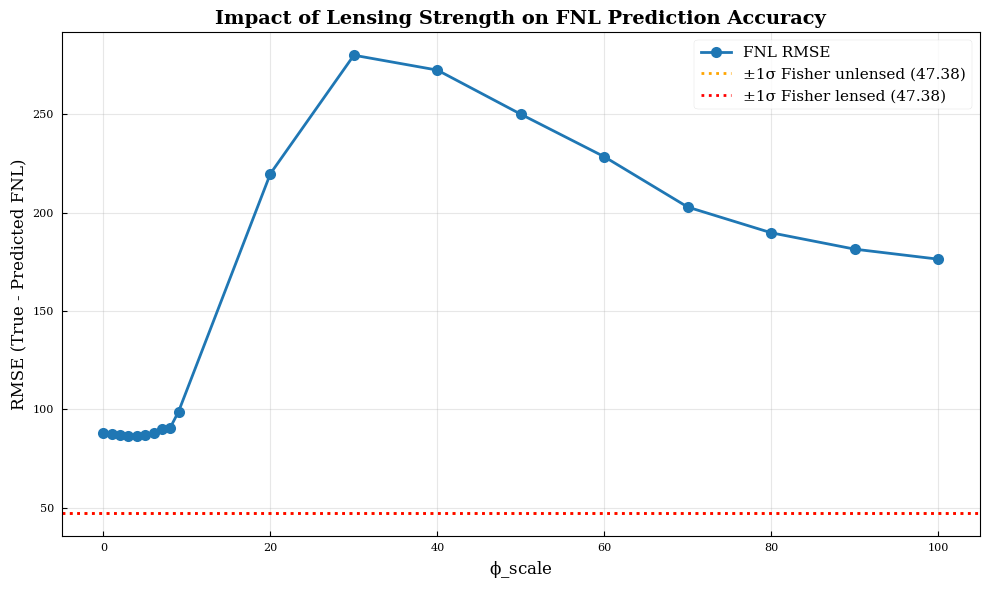

In [20]:
if len(results) > 0:
    phi_vals = np.array([r[0] for r in results])
    rmse_vals = np.array([r[1] for r in results])

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    ax.plot(phi_vals, rmse_vals, "o-", linewidth=2, markersize=8, label="FNL RMSE")

    # Add Fisher information bound if available
    try:
        # Load Fisher data from file
        for shape_name in shapes:
            fisher = get_data(core.file, f"fisher/unlensed/{shape_name}", 0)
            error_band = 1 / np.sqrt(fisher)
            label_band = f"±1σ Fisher unlensed ({error_band:.2f})"
            ax.axhline(
                error_band,
                color="orange",
                linestyle=":",
                linewidth=2,
                label=label_band,
            )

            fisher = get_data(core.file, f"fisher/lensed/{shape_name}", 0)
            error_band = 1 / np.sqrt(fisher)
            label_band = f"±1σ Fisher lensed ({error_band:.2f})"
            ax.axhline(
                error_band,
                color="red",
                linestyle=":",
                linewidth=2,
                label=label_band,
            )
            break  # Use first shape for now
    except Exception as e:
        print(f"Could not load Fisher data: {e}")

    ax.set_xlabel(r"$\phi\_scale$", fontsize=12)
    ax.set_ylabel("RMSE (True - Predicted FNL)", fontsize=12)
    ax.set_title(
        "Impact of Lensing Strength on FNL Prediction Accuracy",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")

## Dataset Verification: Maps and Parameters

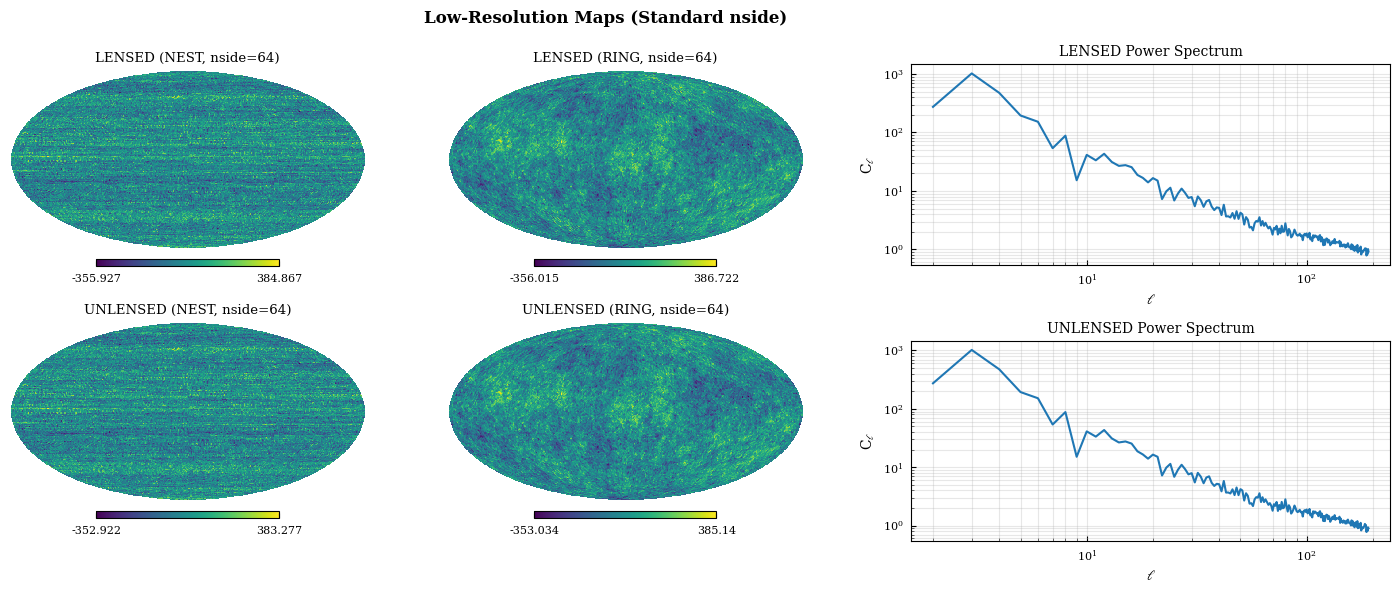

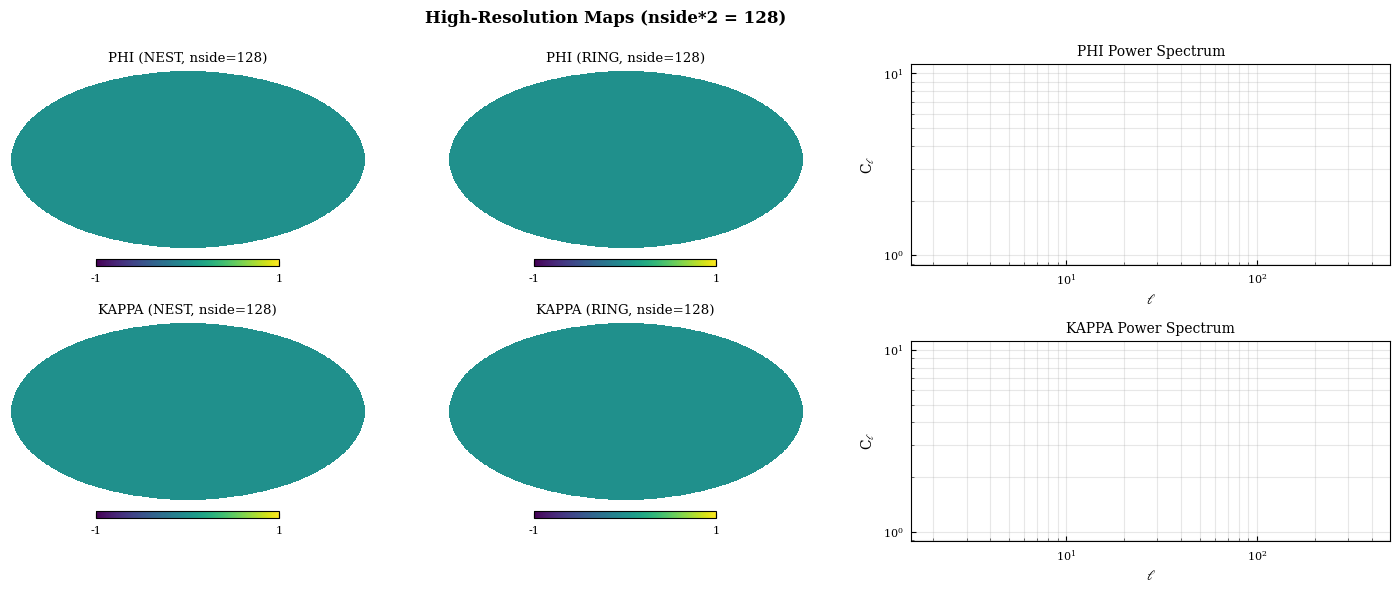

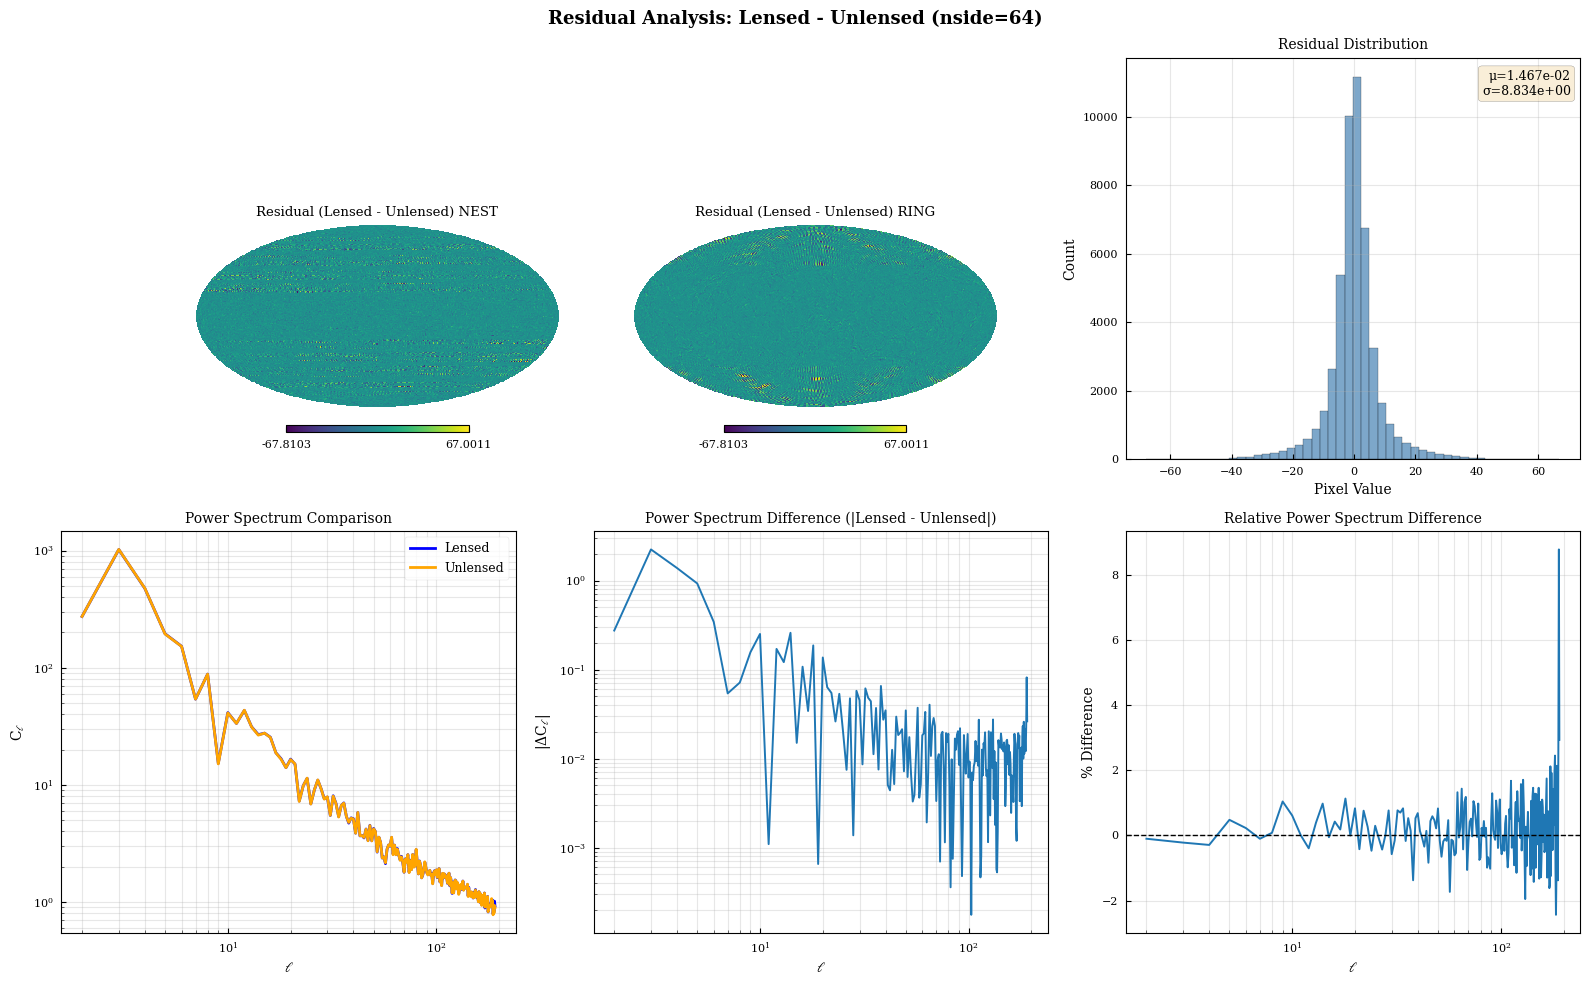

In [21]:
# Plot 2: Dataset Verification - Maps (Mollweide + Power Spectrum)
print("\n" + "=" * 60)
print("Dataset Verification: Maps")
print("=" * 60)

# Create TWO separate datasets to avoid mixing resolutions:
# 1. Low-res maps (lensed, unlensed) at standard nside
# 2. High-res maps (phi, kappa) at nside*2

print("\n--- Low-Resolution Maps (lensed, unlensed) ---")
verif_dataset_lowres = KappaDataset.fromCore(
    core,
    phi_scale=1.0,
    x_output=("lensed", "unlensed"),
    y_output=("fnl",),
    gaussian_mask_prob=0.0,
    parallel_prefer="processes",
)

tf_ds_lowres = verif_dataset_lowres.to_tf(
    gen_batch_size=1,
    duplicates=1,
    cache=False,
    shuffle=False,
    batch_size=1,
)

for batch_x, batch_y in tf_ds_lowres:
    x_lowres = batch_x.numpy()
    break

# Extract low-res maps
maps_lowres = {}
start_idx = 0
for map_type in ["lensed", "unlensed"]:
    map_nest = x_lowres[0, start_idx : start_idx + npix].reshape(npix)
    map_ring = hp.reorder(map_nest, n2r=True)
    maps_lowres[map_type] = {"nest": map_nest, "ring": map_ring}
    start_idx += npix

print("\n--- High-Resolution Maps (phi, kappa) at nside*2 ---")
verif_dataset_hires = KappaDataset.fromCore(
    core,
    phi_scale=0.0,
    kappa_scale=np.sqrt(1e7),
    x_output=("phi", "kappa"),
    y_output=("fnl",),
    gaussian_mask_prob=0.0,
    parallel_prefer="processes",
)

tf_ds_hires = verif_dataset_hires.to_tf(
    gen_batch_size=1,
    duplicates=1,
    cache=False,
    shuffle=False,
    batch_size=1,
)


for batch_x, batch_y in tf_ds_hires:
    x_hires = batch_x.numpy()
    break

# Extract high-res maps (4x pixels)
npix_hires = 4 * npix
maps_hires = {}
start_idx = 0
for map_type in ["phi", "kappa"]:
    map_nest = x_hires[0, start_idx : start_idx + npix_hires].reshape(npix_hires)
    map_ring = hp.reorder(map_nest, n2r=True)
    maps_hires[map_type] = {"nest": map_nest, "ring": map_ring}
    start_idx += npix_hires

# Create verification plots for low-res maps
fig = plt.figure(figsize=(16, 6))

for idx, map_type in enumerate(["lensed", "unlensed"]):
    map_nest = maps_lowres[map_type]["nest"]
    map_ring = maps_lowres[map_type]["ring"]

    # Mollweide projection in NEST ordering
    ax1 = plt.subplot(2, 3, idx * 3 + 1)
    plt.axes(ax1)
    hp.mollview(map_nest, hold=True, remove_dip=True)
    plt.title(f"{map_type.upper()} (NEST, nside={nside})")

    # Mollweide projection in RING ordering
    ax2 = plt.subplot(2, 3, idx * 3 + 2)
    plt.axes(ax2)
    hp.mollview(map_ring, hold=True, remove_dip=True)
    plt.title(f"{map_type.upper()} (RING, nside={nside})")

    # Power spectrum
    ax3 = plt.subplot(2, 3, idx * 3 + 3)
    cl = hp.anafast(map_ring)
    ell = np.arange(len(cl))
    ax3.loglog(ell[2:], cl[2:], linewidth=1.5)
    ax3.set_xlabel("$\\ell$", fontsize=10)
    ax3.set_ylabel("$C_\\ell$", fontsize=10)
    ax3.set_title(f"{map_type.upper()} Power Spectrum", fontsize=10)
    ax3.grid(alpha=0.3, which="both")

plt.suptitle("Low-Resolution Maps (Standard nside)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Create verification plots for high-res maps
fig = plt.figure(figsize=(16, 6))

for idx, map_type in enumerate(["phi", "kappa"]):
    map_nest = maps_hires[map_type]["nest"]
    map_ring = maps_hires[map_type]["ring"]

    # Mollweide projection in NEST ordering
    ax1 = plt.subplot(2, 3, idx * 3 + 1)
    plt.axes(ax1)
    hp.mollview(map_nest, hold=True, remove_dip=True)
    plt.title(f"{map_type.upper()} (NEST, nside={nside*2})")

    # Mollweide projection in RING ordering
    ax2 = plt.subplot(2, 3, idx * 3 + 2)
    plt.axes(ax2)
    hp.mollview(map_ring, hold=True, remove_dip=True)
    plt.title(f"{map_type.upper()} (RING, nside={nside*2})")

    # Power spectrum
    ax3 = plt.subplot(2, 3, idx * 3 + 3)
    cl = hp.anafast(map_ring)
    ell = np.arange(len(cl))
    ax3.loglog(ell[2:], cl[2:], linewidth=1.5)
    ax3.set_xlabel("$\\ell$", fontsize=10)
    ax3.set_ylabel("$C_\\ell$", fontsize=10)
    ax3.set_title(f"{map_type.upper()} Power Spectrum", fontsize=10)
    ax3.grid(alpha=0.3, which="both")

plt.suptitle(
    f"High-Resolution Maps (nside*2 = {nside*2})", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Compute residual maps
residual_nest = maps_lowres["lensed"]["nest"] - maps_lowres["unlensed"]["nest"]
residual_ring = maps_lowres["lensed"]["ring"] - maps_lowres["unlensed"]["ring"]

# Create figure for residuals
fig = plt.figure(figsize=(16, 10))

# Row 1: Residual maps
# Mollweide projection in NEST ordering
ax1 = plt.subplot(2, 3, 1)
plt.axes(ax1)
hp.mollview(residual_nest, hold=True)
plt.title(f"Residual (Lensed - Unlensed) NEST")

# Mollweide projection in RING ordering
ax2 = plt.subplot(2, 3, 2)
plt.axes(ax2)
hp.mollview(residual_ring, hold=True)
plt.title(f"Residual (Lensed - Unlensed) RING")

# Row 1, Col 3: Residual statistics histogram
ax3 = plt.subplot(2, 3, 3)
ax3.hist(residual_ring, bins=50, alpha=0.7, edgecolor="black", color="steelblue")
ax3.set_xlabel("Pixel Value", fontsize=10)
ax3.set_ylabel("Count", fontsize=10)
ax3.set_title("Residual Distribution", fontsize=10)
ax3.grid(alpha=0.3)
res_mean = np.mean(residual_ring)
res_std = np.std(residual_ring)
ax3.text(
    0.98,
    0.97,
    f"μ={res_mean:.3e}\nσ={res_std:.3e}",
    transform=ax3.transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

ax_cl_lensed = plt.subplot(2, 3, 4)
cl_lensed = hp.anafast(maps_lowres["lensed"]["ring"])
cl_unlensed = hp.anafast(maps_lowres["unlensed"]["ring"])
ell = np.arange(len(cl_lensed))
ax_cl_lensed.loglog(ell[2:], cl_lensed[2:], linewidth=2, label="Lensed", color="blue")
ax_cl_lensed.loglog(
    ell[2:], cl_unlensed[2:], linewidth=2, label="Unlensed", color="orange"
)
ax_cl_lensed.set_xlabel("$\\ell$", fontsize=10)
ax_cl_lensed.set_ylabel("$C_\\ell$", fontsize=10)
ax_cl_lensed.set_title("Power Spectrum Comparison", fontsize=10)
ax_cl_lensed.legend(fontsize=9)
ax_cl_lensed.grid(alpha=0.3, which="both")

ax_cl_diff = plt.subplot(2, 3, 5)
cl_diff = cl_lensed - cl_unlensed
ax_cl_diff.loglog(ell[2:], np.abs(cl_diff[2:]))
ax_cl_diff.set_xlabel("$\\ell$", fontsize=10)
ax_cl_diff.set_ylabel("$|\\Delta C_\\ell|$", fontsize=10)
ax_cl_diff.set_title("Power Spectrum Difference (|Lensed - Unlensed|)", fontsize=10)
ax_cl_diff.grid(alpha=0.3, which="both")


ax_cl_reldiff = plt.subplot(2, 3, 6)
cl_reldiff = (cl_lensed - cl_unlensed) / (cl_unlensed + 1e-10)
ax_cl_reldiff.semilogx(ell[2:], cl_reldiff[2:] * 100)
ax_cl_reldiff.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax_cl_reldiff.set_xlabel("$\\ell$", fontsize=10)
ax_cl_reldiff.set_ylabel("% Difference", fontsize=10)
ax_cl_reldiff.set_title("Relative Power Spectrum Difference", fontsize=10)
ax_cl_reldiff.grid(alpha=0.3, which="both")

plt.suptitle(
    f"Residual Analysis: Lensed - Unlensed (nside={nside})",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

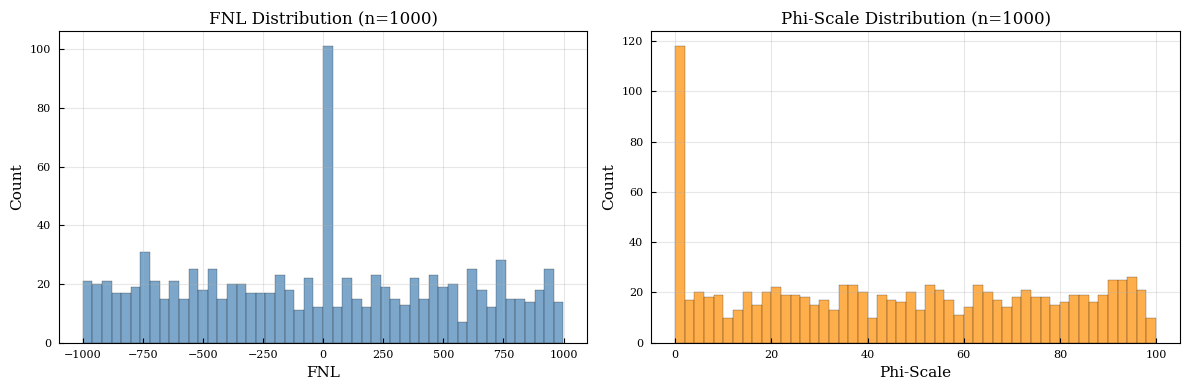

In [22]:
# Plot 3: Dataset Verification - Parameter Distributions
print("\nGenerating 1000 samples for parameter distributions...")
param_dataset = KappaDataset.fromCore(
    core,
    phi_scale=(0, 100),  # Test phi_scale range from 0 to 100
    x_output="lensed",
    y_output=("fnl", "phi_scale"),
    gaussian_mask_prob=0.1,
    parallel_prefer="processes",  # Use processes to avoid stdout hijacking
)

tf_ds_params = param_dataset.to_tf(
    gen_batch_size=32,
    duplicates=1,
    cache=False,
    shuffle=False,
    batch_size=32,
)

# Collect parameters with lenspyx output suppressed
fnl_all = []
phi_scale_all = []
count = 0

for batch_x, batch_y in tqdm(
    tf_ds_params, desc="Collecting parameters", leave=False, total=1000 // 32
):
    y_np = batch_y.numpy()
    fnl_all.append(y_np[:, 0])
    phi_scale_all.append(y_np[:, 1])
    count += len(y_np)
    if count >= 1000:
        break

fnl_all = np.concatenate(fnl_all)[:1000]
phi_scale_all = np.concatenate(phi_scale_all)[:1000]

# Create parameter distribution plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fnl_all, bins=50, alpha=0.7, edgecolor="black", color="steelblue")
axes[0].set_xlabel("FNL", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title(f"FNL Distribution (n={len(fnl_all)})", fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].hist(phi_scale_all, bins=50, alpha=0.7, color="darkorange", edgecolor="black")
axes[1].set_xlabel("Phi-Scale", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title(f"Phi-Scale Distribution (n={len(phi_scale_all)})", fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Saved: dataset_verification_params.png")

print("\n" + "=" * 60)
print("Dataset verification complete!")
print("=" * 60)

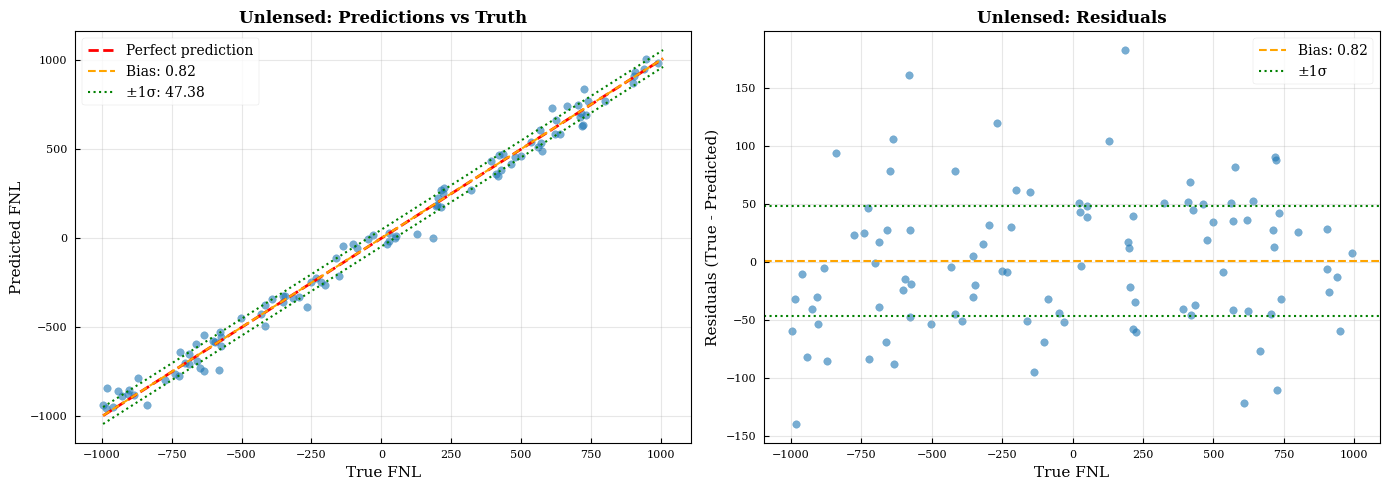

In [23]:
# Predictions on Unlensed Data
print("\n" + "=" * 60)
print("Model Predictions: Unlensed vs Truth")
print("=" * 60)

# Create dataset with unlensed maps
unlensed_dataset = KappaDataset.fromCore(
    core,
    phi_scale=1.0,
    x_output="unlensed",
    y_output=("fnl",),
    gaussian_mask_prob=0.0,
    parallel_prefer="processes",  # Use processes to avoid stdout hijacking
)

tf_ds_unlensed = unlensed_dataset.to_tf(
    gen_batch_size=32,
    duplicates=1,
    cache=False,
    shuffle=False,
    batch_size=32,
)

# Collect 100 samples
x_unlensed = []
y_unlensed_true = []
count = 0

for batch_x, batch_y in tqdm(
    tf_ds_unlensed, desc="Collecting unlensed samples", leave=False
):
    x_unlensed.append(batch_x.numpy())
    y_unlensed_true.append(batch_y.numpy())
    count += len(batch_x)
    if count >= 100:
        break

x_unlensed = np.concatenate(x_unlensed, axis=0)[:100]
y_unlensed_true = np.concatenate(y_unlensed_true, axis=0)[:100]

# Predict FNL

y_unlensed_pred = fnl_model.predict(x_unlensed, verbose=0)

# Compute statistics
unlensed_rmse = np.sqrt(np.mean((y_unlensed_true - y_unlensed_pred) ** 2))
unlensed_bias = np.mean(y_unlensed_true - y_unlensed_pred)

# Load Fisher bound for std
try:
    fisher = get_data(core.file, f"fisher/unlensed/{shapes[0]}", 0)
    unlensed_std = 1 / np.sqrt(fisher)
except Exception as e:
    print(f"Could not load Fisher data, using empirical std: {e}")
    unlensed_std = np.std(y_unlensed_true - y_unlensed_pred)

print(f"RMSE: {unlensed_rmse:.4f}")
print(f"Bias: {unlensed_bias:.4f}")
print(f"Std Dev: {unlensed_std:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: predictions vs truth
ax1.scatter(y_unlensed_true, y_unlensed_pred, alpha=0.6, s=30)
min_val = min(y_unlensed_true.min(), y_unlensed_pred.min())
max_val = max(y_unlensed_true.max(), y_unlensed_pred.max())
ax1.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect prediction",
)
# Plot bias line (true value line shifted by bias)
ax1.plot(
    [min_val, max_val],
    [min_val + unlensed_bias, max_val + unlensed_bias],
    "orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Bias: {unlensed_bias:.2f}",
)
# Plot ±1σ bands around bias line
ax1.plot(
    [min_val, max_val],
    [min_val + unlensed_bias + unlensed_std, max_val + unlensed_bias + unlensed_std],
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"±1σ: {unlensed_std:.2f}",
)
ax1.plot(
    [min_val, max_val],
    [min_val + unlensed_bias - unlensed_std, max_val + unlensed_bias - unlensed_std],
    color="green",
    linestyle=":",
    linewidth=1.5,
)
ax1.set_xlabel("True FNL", fontsize=11)
ax1.set_ylabel("Predicted FNL", fontsize=11)
ax1.set_title("Unlensed: Predictions vs Truth", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Residuals plot
residuals = y_unlensed_true - y_unlensed_pred
ax2.scatter(y_unlensed_true, residuals, alpha=0.6, s=30)
ax2.axhline(
    unlensed_bias,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Bias: {unlensed_bias:.2f}",
)
ax2.axhline(
    unlensed_bias + unlensed_std,
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"±1σ",
)
ax2.axhline(unlensed_bias - unlensed_std, color="green", linestyle=":", linewidth=1.5)
ax2.set_xlabel("True FNL", fontsize=11)
ax2.set_ylabel("Residuals (True - Predicted)", fontsize=11)
ax2.set_title("Unlensed: Residuals", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

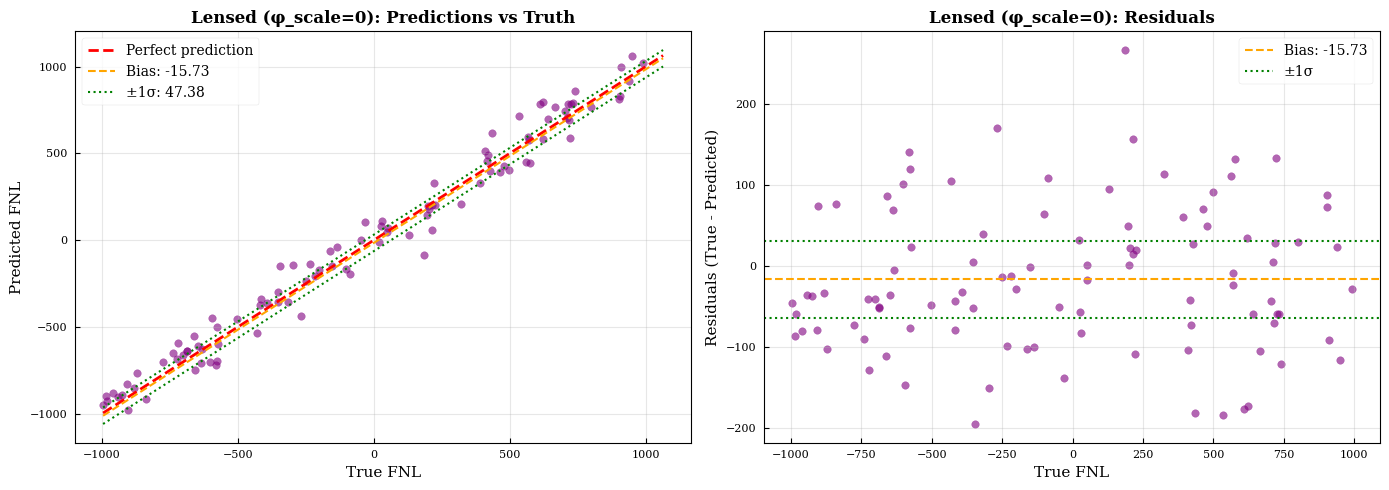

In [24]:
# Predictions on Lensed Data (phi_scale=0)
print("\n" + "=" * 60)
print("Model Predictions: Lensed (phi_scale=0) vs Truth")
print("=" * 60)

# Create dataset with lensed maps at phi_scale=0 (no lensing)
lensed_phi0_dataset = KappaDataset.fromCore(
    core,
    phi_scale=0.0,
    x_output="lensed",
    y_output=("fnl",),
    gaussian_mask_prob=0.0,
    parallel_prefer="processes",  # Use processes to avoid stdout hijacking
)

tf_ds_lensed_phi0 = lensed_phi0_dataset.to_tf(
    gen_batch_size=32,
    duplicates=1,
    cache=False,
    shuffle=False,
    batch_size=32,
)

# Collect 100 samples
x_lensed_phi0 = []
y_lensed_phi0_true = []
count = 0

for batch_x, batch_y in tqdm(
    tf_ds_lensed_phi0, desc="Collecting lensed (phi=0) samples", leave=False
):
    x_lensed_phi0.append(batch_x.numpy())
    y_lensed_phi0_true.append(batch_y.numpy())
    count += len(batch_x)
    if count >= 100:
        break

x_lensed_phi0 = np.concatenate(x_lensed_phi0, axis=0)[:100]
y_lensed_phi0_true = np.concatenate(y_lensed_phi0_true, axis=0)[:100]

# Predict FNL

y_lensed_phi0_pred = fnl_model.predict(x_lensed_phi0, verbose=0)

# Compute statistics
lensed_phi0_rmse = np.sqrt(np.mean((y_lensed_phi0_true - y_lensed_phi0_pred) ** 2))
lensed_phi0_bias = np.mean(y_lensed_phi0_true - y_lensed_phi0_pred)

# Load Fisher bound for std
try:
    fisher = get_data(core.file, f"fisher/lensed/{shapes[0]}", 0)
    lensed_phi0_std = 1 / np.sqrt(fisher)
except Exception as e:
    print(f"Could not load Fisher data, using empirical std: {e}")
    lensed_phi0_std = np.std(y_lensed_phi0_true - y_lensed_phi0_pred)

print(f"RMSE: {lensed_phi0_rmse:.4f}")
print(f"Bias: {lensed_phi0_bias:.4f}")
print(f"Std Dev: {lensed_phi0_std:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: predictions vs truth
ax1.scatter(y_lensed_phi0_true, y_lensed_phi0_pred, alpha=0.6, s=30, color="purple")
min_val = min(y_lensed_phi0_true.min(), y_lensed_phi0_pred.min())
max_val = max(y_lensed_phi0_true.max(), y_lensed_phi0_pred.max())
ax1.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect prediction",
)
# Plot bias line (true value line shifted by bias)
ax1.plot(
    [min_val, max_val],
    [min_val + lensed_phi0_bias, max_val + lensed_phi0_bias],
    "orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Bias: {lensed_phi0_bias:.2f}",
)
# Plot ±1σ bands around bias line
ax1.plot(
    [min_val, max_val],
    [
        min_val + lensed_phi0_bias + lensed_phi0_std,
        max_val + lensed_phi0_bias + lensed_phi0_std,
    ],
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"±1σ: {lensed_phi0_std:.2f}",
)
ax1.plot(
    [min_val, max_val],
    [
        min_val + lensed_phi0_bias - lensed_phi0_std,
        max_val + lensed_phi0_bias - lensed_phi0_std,
    ],
    color="green",
    linestyle=":",
    linewidth=1.5,
)
ax1.set_xlabel("True FNL", fontsize=11)
ax1.set_ylabel("Predicted FNL", fontsize=11)
ax1.set_title(
    "Lensed (φ_scale=0): Predictions vs Truth", fontsize=12, fontweight="bold"
)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Residuals plot
residuals = y_lensed_phi0_true - y_lensed_phi0_pred
ax2.scatter(y_lensed_phi0_true, residuals, alpha=0.6, s=30, color="purple")
ax2.axhline(
    lensed_phi0_bias,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Bias: {lensed_phi0_bias:.2f}",
)
ax2.axhline(
    lensed_phi0_bias + lensed_phi0_std,
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"±1σ",
)
ax2.axhline(
    lensed_phi0_bias - lensed_phi0_std, color="green", linestyle=":", linewidth=1.5
)
ax2.set_xlabel("True FNL", fontsize=11)
ax2.set_ylabel("Residuals (True - Predicted)", fontsize=11)
ax2.set_title("Lensed (φ_scale=0): Residuals", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Benchmark: processes vs Threads Parallelization

In [ ]:
# Benchmark: Compare processes vs Threads Performance
print("\n" + "=" * 60)
print("Benchmark: Dataset Generation - processes vs Threads")
print("=" * 60)

import time

# Test configuration
gen_batch_size = 16
duplicates = 1
batch_size = 32

results_benchmark = []

for prefer_mode in ["processes", "threads"]:
    print(f"\nTesting with prefer='{prefer_mode}'...")

    # Create dataset with specified parallel preference
    bench_dataset = KappaDataset.fromCore(
        core,
        phi_scale=1.0,
        x_output="lensed",
        y_output=("fnl",),
        gaussian_mask_prob=0.0,
        parallel_prefer=prefer_mode,
    )

    # Generate TensorFlow dataset
    print(f"  Building TF dataset pipeline...")
    tf_ds_bench = bench_dataset.to_tf(
        gen_batch_size=gen_batch_size,
        duplicates=duplicates,
        cache=False,
        shuffle=False,
        batch_size=batch_size,
    )

    # Warm-up: iterate once to avoid initialization overhead
    print(f"  Warm-up iteration...")

    for _ in tf_ds_bench.take(1):
        pass

    # Benchmark: time the generation of 5 batches
    print(f"  Benchmarking 5 iterations...")
    start_time = time.time()
    batch_count = 0

    for batch_x, batch_y in tf_ds_bench.take(5):
        batch_count += 1

    elapsed_time = time.time() - start_time

    avg_time_per_batch = elapsed_time / batch_count

    results_benchmark.append(
        {
            "prefer": prefer_mode,
            "total_time": elapsed_time,
            "avg_per_batch": avg_time_per_batch,
            "batches": batch_count,
        }
    )

    print(f"  Total time: {elapsed_time:.2f}s")
    print(f"  Avg per batch: {avg_time_per_batch:.2f}s")
    print(f"  Batches processed: {batch_count}")

# Print comparison summary
print("\n" + "-" * 60)
print("Summary:")
print("-" * 60)
for result in results_benchmark:
    print(
        f"  {result['prefer']:8s}: {result['total_time']:6.2f}s total, {result['avg_per_batch']:6.2f}s/batch"
    )

if len(results_benchmark) == 2:
    processes_time = next(
        r["avg_per_batch"] for r in results_benchmark if r["prefer"] == "processes"
    )
    threads_time = next(
        r["avg_per_batch"] for r in results_benchmark if r["prefer"] == "threads"
    )
    speedup = threads_time / processes_time
    print(f"\n  Speedup (threads/processes): {speedup:.2f}x")
    if speedup > 1:
        print(f"  → Threads is {(speedup-1)*100:.1f}% faster")
    else:
        print(f"  → processes is {(1-speedup)*100:.1f}% faster")

print("=" * 60)

20-Nov-25 08:59:20 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n64.json', '--nsims', '10000', '--shapes', 'local', '--fnl_range', '-1000', '1000']
20-Nov-25 08:59:20 - mlpng.core - INFO - Loading settings from file 'settings/n64.json'
20-Nov-25 08:59:20 - mlpng.core - DEBUG - Forcing setting 'nsims' to 10000 due to CLI
20-Nov-25 08:59:20 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-1000, 1000] due to CLI
20-Nov-25 08:59:20 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
20-Nov-25 08:59:20 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.105e-09
20-Nov-25 08:59:20 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.965
20-Nov-25 08:59:20 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.105e-09,
    "ns": 0.965,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 10000,
  "nside": 64,
  "fnl_range": [
    -1000,
   

In [26]:
print()